#### Import Libraries

In [1]:
import numpy as np
import pandas as pd

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics 
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)

#### Load Dataset

In [2]:
import sys
!{sys.executable} -m pip install openpyxl

In [3]:
df=pd.read_excel("../Data/Flight_Fare.xlsx")

#### Basic Data Inspection

In [4]:
df.sample(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10376,Air Asia,12/06/2019,Banglore,Delhi,BLR → DEL,23:55,02:45 13 Jun,2h 50m,non-stop,No info,3383
10305,SpiceJet,18/03/2019,Chennai,Kolkata,MAA → CCU,08:20,10:35,2h 15m,non-stop,No check-in baggage included,3807
3630,Jet Airways,6/06/2019,Kolkata,Banglore,CCU → BOM → BLR,21:10,04:40 07 Jun,7h 30m,1 stop,No info,13374
3860,Air Asia,9/06/2019,Kolkata,Banglore,CCU → DEL → BLR,07:35,19:25,11h 50m,1 stop,No info,7870
9907,Air India,03/03/2019,Banglore,New Delhi,BLR → BBI → DEL,09:30,16:20,6h 50m,1 stop,No info,11654


In [5]:
df.shape

(10683, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [7]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


#### Check Missing Values

In [8]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

#### Remove Missing Values

In [9]:
df.dropna(inplace=True)

#### Check Duplicated Values

In [10]:
df.duplicated().sum()

np.int64(220)

In [11]:
df[df.duplicated()]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
683,Jet Airways,1/06/2019,Delhi,Cochin,DEL → NAG → BOM → COK,14:35,04:25 02 Jun,13h 50m,2 stops,No info,13376
1061,Air India,21/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 22 May,21h 15m,2 stops,No info,10231
1348,Air India,18/05/2019,Delhi,Cochin,DEL → HYD → BOM → COK,17:15,19:15 19 May,26h,2 stops,No info,12392
1418,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,05:30,04:25 07 Jun,22h 55m,2 stops,In-flight meal not included,10368
1674,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,18:25,21:20,2h 55m,non-stop,No info,7303
...,...,...,...,...,...,...,...,...,...,...,...
10594,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,12:35 28 Jun,13h 30m,2 stops,No info,12819
10616,Jet Airways,1/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,12:35 02 Jun,26h 55m,2 stops,No info,13014
10634,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,12:35 07 Jun,26h 55m,2 stops,In-flight meal not included,11733
10672,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,19:00 28 Jun,19h 55m,2 stops,In-flight meal not included,11150


#### Drop Duplicated Values

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

#### Exploratory Data Analysis(EDA)

#### Univariate Analysis

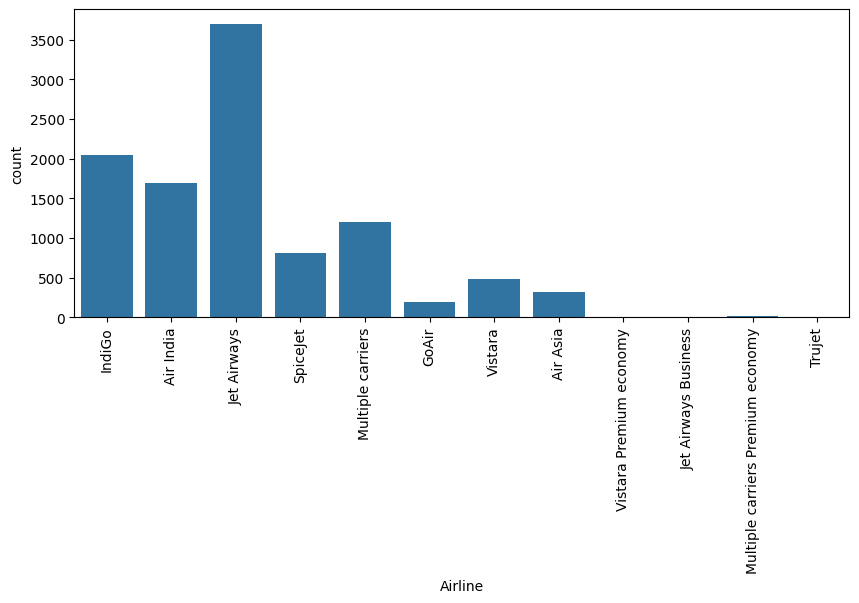

In [14]:
plt.figure(figsize=(10,4))
sns.countplot(x=df["Airline"])
plt.xticks(rotation=90)
plt.show()

- Jet Airways has the highest number of flight travel records followed by IndiGo and Air India.
- Some airlines have few travel records , indicating imbalance in the feature distribution.

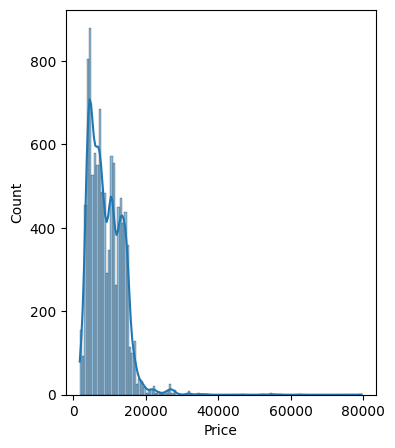

In [15]:
plt.figure(figsize=(4,5))
sns.histplot(df["Price"],kde=True)
plt.show()

- The price distribution is highly right skewed showing the presence of outliers.
- It shows multiple peaks in the range between 0-20000.

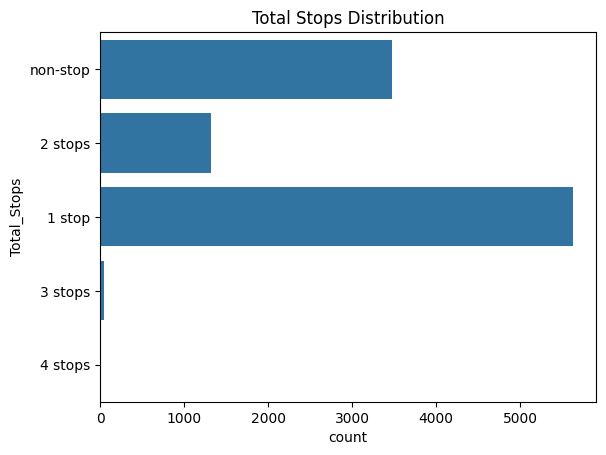

In [16]:
sns.countplot(df["Total_Stops"])
plt.title("Total Stops Distribution")
plt.show()

- Most flights have 1 stops.
- Non stop flights are comparatively fewer.

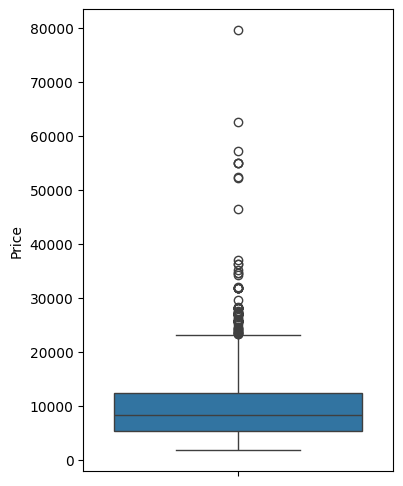

In [17]:
plt.figure(figsize=(4,6))
sns.boxplot(df["Price"])
plt.show()

- There are some outliers present in the dataset.

- There are some outliers present in the dataset.

#### Bivariate Analysis

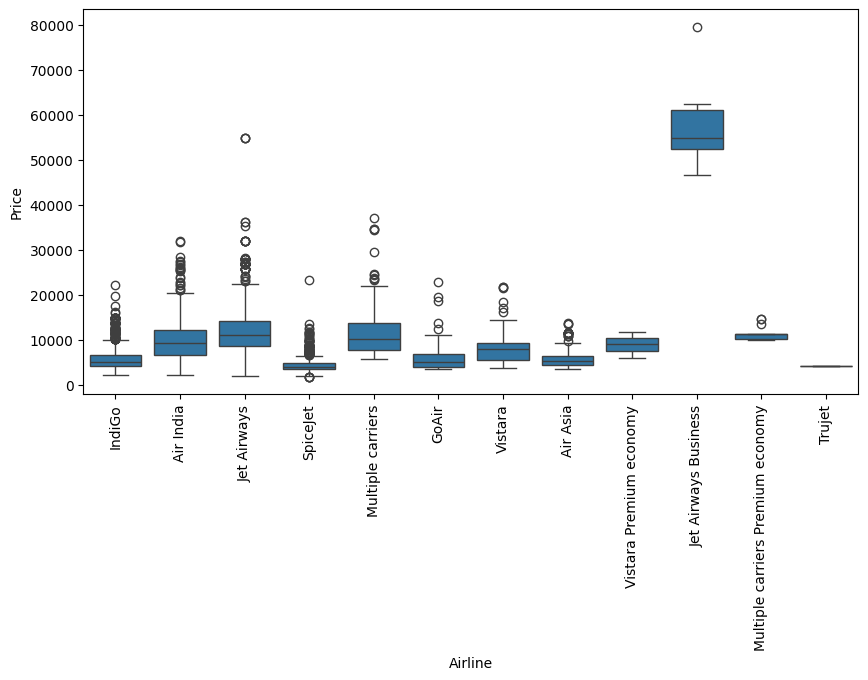

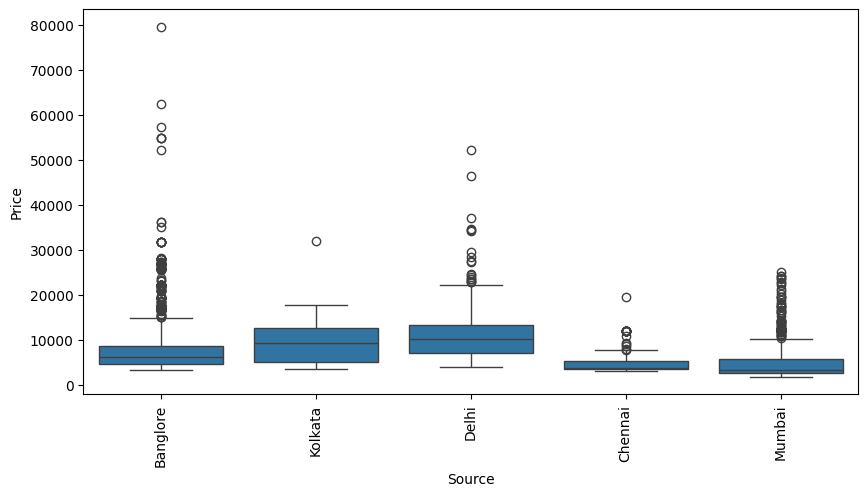

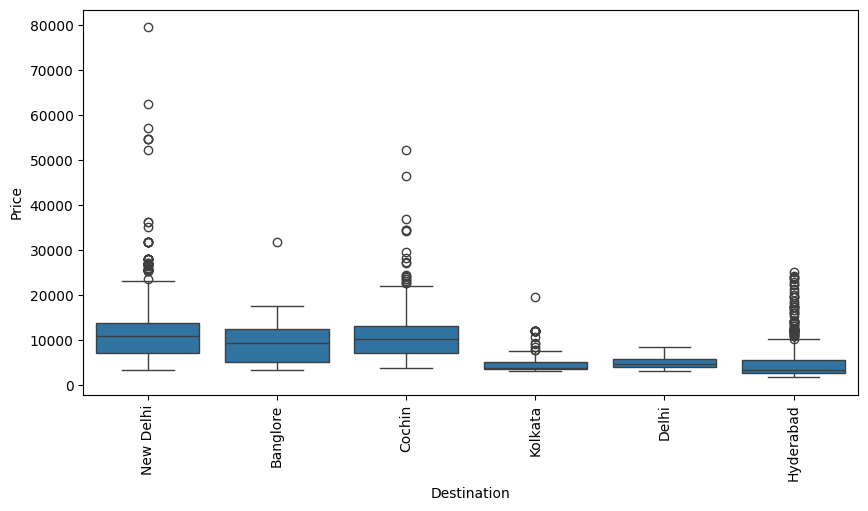

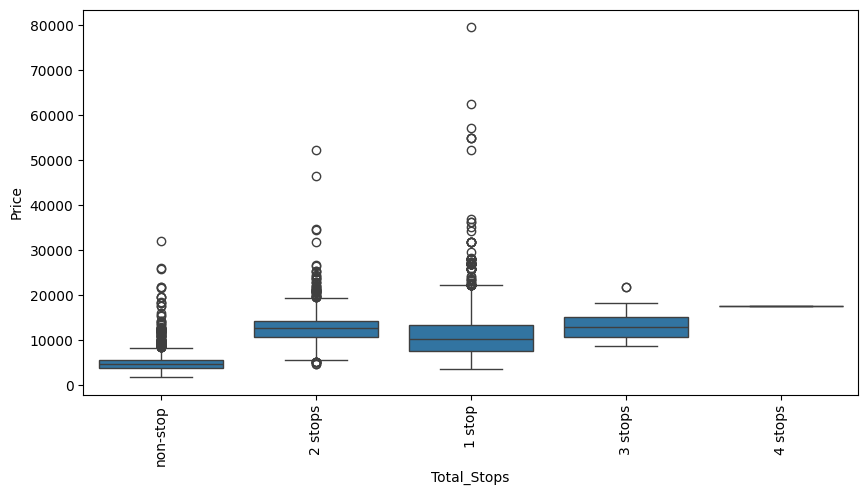

In [18]:
imp_categorical_columns=[
    "Airline",
    "Source",
    "Destination",
    "Total_Stops"
]
for col in imp_categorical_columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=col,y="Price",data=df)
    plt.xticks(rotation=90)
    plt.show()

Price vs Airlines
- Jet airways has the highest ticket price and the widest price variation,showing that buiness class flight are more expensive.
- Low cost airlines like Indigo,SpiceJet have lower median fares with smaller price ranges.

Price vs Souce
- Flights departing from Kolkata and Delhi show higher median ticket prices compared to Mumbai and Chennai,indicating travelling from these cities are in high demand.
- Bangalore and Delhi contain several outliers, which suggests some flights from these cities are quite expensive.

Price vs Destination
- Flights destined for New Delhi and Cochin have higher median ticker price indicating travel to these cities are generally expensive.
- New Delhi and Cochin show several high price outliers suggesting the presene of premium or coostly bookings.

Price vs Total_Stops 
- Flights with more stops generally have higher median ticket prices compared to non-stop flights indicating ticket cost increase with the number of stops.
- Flights with 1 stop and 2 stop show several extreme outliers suggesting high variability in fares due to factors such as airline type,traverl duration.

### Feature Engineering

#### Date Feature Engineering

In [19]:
df["Journey_Day"]=pd.to_datetime(df["Date_of_Journey"]).dt.day

df["Journey_Month"]=pd.to_datetime(df["Date_of_Journey"]).dt.month

# drop the original column
df.drop("Date_of_Journey",axis=1,inplace=True)

- Day and month influence the seasonal ticket price.
- Raw date column is not useful for ml.

#### Departure Time Feature Engineering

In [20]:
df["Dep_Hour"]=pd.to_datetime(df["Dep_Time"]).dt.hour

df["Dep_Min"]=pd.to_datetime(df["Dep_Time"]).dt.minute

df.drop("Dep_Time",axis=1,inplace=True)

- Departure time affects the ticket price.
- Morning and evening flight may cost differently.

#### Arrival Time Feature Engineering

In [21]:
df["Arrival_Hour"]=pd.to_datetime(df["Arrival_Time"]).dt.hour

df["Arrival_Min"]=pd.to_datetime(df["Arrival_Time"]).dt.minute

df.drop("Arrival_Time",axis=1,inplace=True)

- Arrival time can affect fare prices.

#### Duration Feature Engineering

In [22]:
Duration=list(df["Duration"])

for i in range(len(Duration)):
    if len(Duration[i].split()) != 2:
        if "h"  in Duration[i]:
            Duration[i]= Duration[i]+" 0m"
        else:
            Duration[i]="0h " + Duration[i]

# extract hours and minutes
Duration_Hour=[]
Duration_Min=[]

for i in range(len(Duration)):
    Duration_Hour.append(int(Duration[i].split(sep="h")[0]))
    Duration_Min.append(int(Duration[i].split(sep="m")[0].split()[-1]))

df["Duration_Hour"]=Duration_Hour
df["Duration_Min"]=Duration_Min

df.drop("Duration",axis=1,inplace=True)

- Travel duration strongly affects the price.
- Long duration flights are cheaper.

#### Convert Total Stops into Numerical Value

In [23]:
df["Total_Stops"]=df["Total_Stops"].map({
    "non-stop": 0,
    "1 stop" : 1,
    "2 stops" : 2,
    "3 stops" : 3,
    "4 stops" : 4
})

- Ml model works better with numerical features.

#### Drop Unnecessary Column

In [24]:
df.drop(["Route","Additional_Info"],axis=1,inplace=True)

- Removing irrelevant features reduce noise.

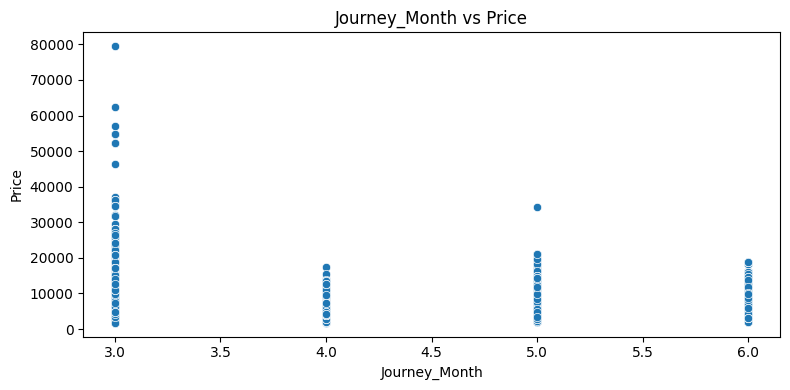

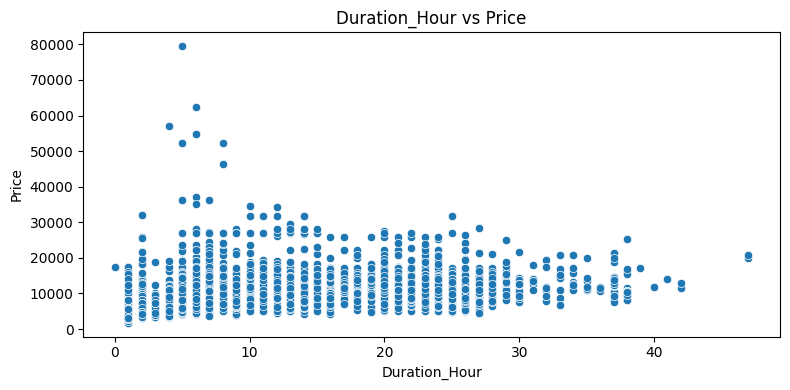

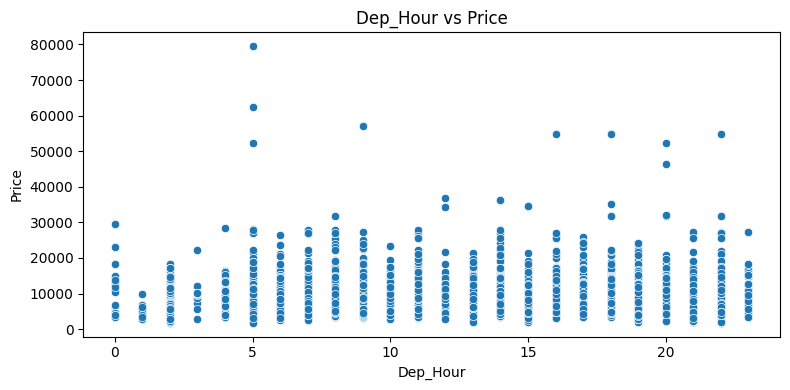

In [25]:
numerical_columns=[
    "Journey_Month",
    "Duration_Hour",
    "Dep_Hour"
]
for col in numerical_columns:
    plt.figure(figsize=(8,4))
    sns.scatterplot(x=col,y="Price",data=df)
    plt.title(f"{col} vs Price")
    plt.tight_layout()
    plt.show()

Journey_Month vs Price
- Flight Prices in March(Journey_Month=3) contain the most expensive tickets, indicating that fares were significantly  higher during this month.

Duration_Hour vs Price
- Flights taking less than 10 hours appear to be more expensive  than many longer duration flights.

Dep_Hour vs Price
- Flight Prices are distributed across all departure hours, but some of the high-priced tickets are concentrated during early morning and evening.

#### Correlation Heatmap

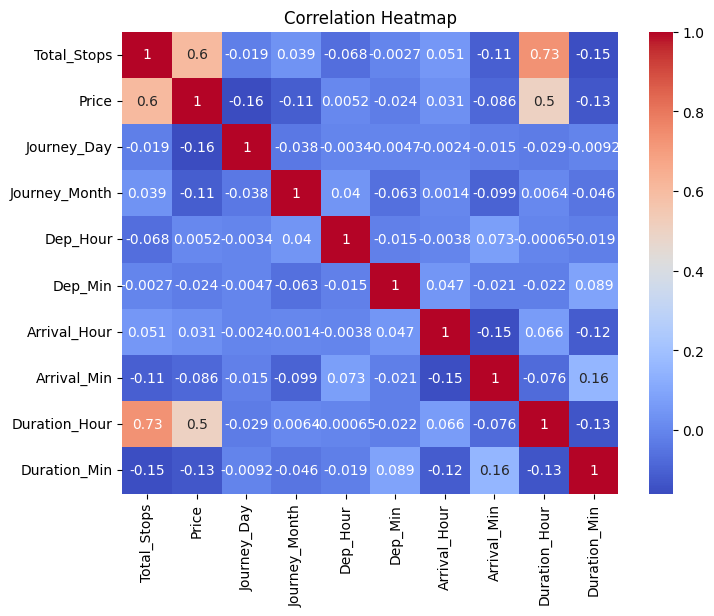

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

- Price has a moderate positive correlation with Total_Stops and Duration_Hour, indicating that flights with more stops and longer durations tend to be more expensive.
- Most other features have very weak correlations with price, suggesting they have less direct impact on ticket prices.

#### Separate Features and Targets

In [27]:
x=df.drop("Price",axis=1)
y=df["Price"]

#### Apply One Hot Encoding

In [28]:
categorical_columns=[
    "Airline",
    "Source",
    "Destination"
]

preprocessor=ColumnTransformer(transformers=[
    ("OHE",OneHotEncoder(handle_unknown="ignore"),categorical_columns)
],remainder="passthrough")

- ML models can't understand text directly.
- One Hot Encoding converts text data into numerical value.

#### Train Test Split

In [29]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

#### Linear Regression Model

In [30]:
lr_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",LinearRegression())
])

lr_pipeline.fit(x_train,y_train)
y_pred_lr=lr_pipeline.predict(x_test)

#### Decision Tree Regressor

In [31]:
dt_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",DecisionTreeRegressor())
])

dt_pipeline.fit(x_train,y_train)
y_pred_dt=dt_pipeline.predict(x_test)

#### Random Forest Regressor

In [32]:
rf_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline.fit(x_train,y_train)
y_pred_rf=rf_pipeline.predict(x_test)

#### XGB Regressor

In [33]:
xgb_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    ))
])

xgb_pipeline.fit(x_train,y_train)
y_pred_xgb=xgb_pipeline.predict(x_test)

#### Create Evaluation Function

In [34]:
def evaluate_model(y_test,y_pred):
    mae = mean_absolute_error(y_test,y_pred)
    mse = mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)

    return mae,mse,r2

In [35]:
# evaluate linear regression

lr_results = evaluate_model(y_test,y_pred_lr)

# evaluate decision tree regresssor

dt_results = evaluate_model(y_test,y_pred_dt)

# evaluate random forest regressor

rf_results = evaluate_model(y_test,y_pred_rf)

# evaluate xgboost regressor

xgb_results = evaluate_model(y_test,y_pred_xgb)


In [36]:
comparison_df = pd.DataFrame({
    "Models" : [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "XGB Regressor"
    ],
    
    "MAE" : [
        lr_results[0],
        dt_results[0],
        rf_results[0],
        xgb_results[0]
    ],
    
    "MSE" : [
        lr_results[1],
        dt_results[1],
        rf_results[1],
        xgb_results[1]
    ],
    
    "R2" : [
        lr_results[2],
        dt_results[2],
        rf_results[2],
        xgb_results[2]
    ]
})

In [37]:
comparison_df.sort_values(by="R2",ascending=False)

,Models,MAE,MSE,R2
3,XGB Regressor,1251.701294,3.606010e+06,0.827052
2,Random Forest Regressor,1181.779900,3.910185e+06,0.812464
1,Decision Tree Regressor,1386.072504,6.081066e+06,0.708346
0,Linear Regression,1998.899686,8.678835e+06,0.583754


#### Select the Best Model

In [38]:
best_model=comparison_df.sort_values(by="R2",ascending=False).iloc[0]["Models"]

print(best_model)

XGB Regressor


- XGBoost achieved the highest r2 score, indicating the best predictive performance.
- Ensemble models performed better than linear models by capturing comple non-linear relationships.

#### Hyperparameter Tuning

In [39]:
from sklearn.model_selection import RandomizedSearchCV

params={
    "model__n_estimators"  : [100,200,300],
    "model__learning_rate" : [0.01,0.05,0.1],
    "model__max_depth"     : [4,6,8,10],
    "model__subsample" : [0.7,0.8,0.10]
}

random_search = RandomizedSearchCV(estimator=xgb_pipeline,param_distributions=params,n_iter=50,scoring="r2",cv=5,random_state=42)

# Train Tuning
random_search.fit(x_train,y_train)

# best parameters
print(random_search.best_params_)

# best model
best_xgb = random_search.best_estimator_

# prediction
y_pred = best_xgb.predict(x_test)

# final r2_score
r2 = r2_score(y_test,y_pred)
print(r2)

{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 6, 'model__learning_rate': 0.1}
0.8362284898757935


#### Select Final Model

In [40]:
Final_model=xgb_pipeline

#### Save Final Model

In [43]:
import pickle
pickle.dump(Final_model,open("flight_fare_model.pkl","wb"))

#### Load Saved Model

In [44]:
model=pickle.load(open("flight_fare_model.pkl","rb"))

#### Final Project Conclusion 

- Performed complete data preprocessing and feature engineering.
- Built and compared multiple regression models.
- XGBoost achieved best performance.
- Important features were duration, airline, stops, and journey month.